<center><img src="img/banner.jpeg" width=1200px /></center>

<center><h1><b><span style="color: green">Translational Neuroscience School 2026</b></span></h1></center>

## Objetivo

En los notebooks anteriores aprendimos a:
1. Ganar una intuición acerca de qué es la derivada
2. Calcular la pendiente (slope) de un fEPSP individual (sintético)

Ahora damos un paso important: Calcular las pendientes y compararlas a los datos del estudio.

## 1. Preparación

In [2]:
%matplotlib widget
import scipy
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from IPython.display import display
from scipy import stats
from scipy.signal import savgol_filter

data = scipy.io.matlab.loadmat("data/mousedata.mat", simplify_cells=True)
print("Datos cargados.")

Datos cargados.


## 2. Funciones base

(Solo ejecutar).

In [3]:
def get_fepsp_trace(data, group, mouse_n, phase, channel_n, num_pulse, wo_stim_art=False, savgol = False):
    """Extrae una traza fEPSP del dataset."""
    if group == 'shocked' and mouse_n >= 24:
        return None
    if group == 'control' and mouse_n >= 12:
        return None

    chan = data['dd']['raw'][group]['mouse'][mouse_n][phase]['chan']

    if isinstance(chan, dict):
        if channel_n > 0:
            return None
        if num_pulse >= len(chan['stim_pulses']):
            return None
        trace = chan['stim_pulses'][num_pulse]['y']
        if wo_stim_art:
            offset = 1500
            trace = trace[chan['stim_pulses'][num_pulse]['rel_t'] - offset > 0]
        return trace

    if channel_n >= len(chan):
        return None
    if num_pulse >= len(chan[channel_n]['stim_pulses']):
        return None
    trace = chan[channel_n]['stim_pulses'][num_pulse]['y']
    if wo_stim_art:
        offset = 1500
        trace = trace[chan[channel_n]['stim_pulses'][num_pulse]['rel_t'] - offset > 0]

    if savgol:
        trace = savgol_filter(trace, window_length=31, polyorder=3)
        
    return trace


def calculate_slope_dn_method(trace, d=1, sr=16000, samp_window=10):
    """Calcula la pendiente usando la derivada de orden d."""
    dtrace = np.copy(trace)
    dt = 1.0 / sr
    for i in range(d):
        dtrace = np.gradient(dtrace, dt)

    peak_d1_pos = np.argmin(dtrace)
    left_limit = peak_d1_pos - samp_window
    right_limit = peak_d1_pos + samp_window

    x_fit = np.arange(left_limit, right_limit)
    y_fit = trace[left_limit:right_limit]
    slope_V_samp, intercept = np.polyfit(x_fit, y_fit, 1)
    slope_V_sec = slope_V_samp * sr

    return slope_V_sec, slope_V_samp, intercept, left_limit, right_limit

---

## 3. Extracción masiva de slopes

Iteramos sobre todo el dataset. Para cada traza extraemos nuestro slope (calculado con primera derivada + ventana) y el slope de los autores: guardado en la estructura de datos original. Los resultados se guardan en un diccionario de arrays numpy.

In [23]:
def batch_slope_extraction(data, sr=16000, samp_window=10, d=1, savgol = False):
    """
    Extrae el slope de todas las trazas del dataset.
    
    Returns: dict con arrays paralelos:
        'group', 'mouse', 'phase', 'channel', 'pulse', 'slope_ours', 'slope_authors'
    """
    groups_list = []
    mice_list = []
    phases_list = []
    channels_list = []
    pulses_list = []
    slopes_ours = []
    slopes_authors = []
    
    groups_info = {'shocked': 24, 'control': 12}
    phases = ['pre', 'post']
    
    for group, n_mice in groups_info.items():
        for mouse_n in range(n_mice):
            for phase in phases:
                chan = data['dd']['raw'][group]['mouse'][mouse_n][phase]['chan']
                
                if isinstance(chan, dict):
                    n_channels = 1
                else:
                    n_channels = len(chan)
                
                for channel_n in range(n_channels):
                    if isinstance(chan, dict):
                        n_pulses = len(chan['stim_pulses'])
                    else:
                        n_pulses = len(chan[channel_n]['stim_pulses'])
                    
                    for pulse in range(n_pulses):
                        # Slope de los autores
                        try:
                            if isinstance(chan, dict):
                                slope_auth = chan['stim_pulses'][pulse]['fepsp_slope']
                            else:
                                slope_auth = chan[channel_n]['stim_pulses'][pulse]['fepsp_slope']
                        except Exception:
                            slope_auth = np.nan
                        
                        # Nuestro slope
                        trace = get_fepsp_trace(data, group, mouse_n, phase,
                                                channel_n, pulse, wo_stim_art=True, savgol = savgol)
                        if trace is None:
                            slope_ours_val = np.nan
                        else:
                            try:
                                slope_ours_val, _, _, _, _ = calculate_slope_dn_method(
                                    trace, d=d, sr=sr, samp_window=samp_window
                                )
                            except Exception:
                                slope_ours_val = np.nan
                        
                        groups_list.append(group)
                        mice_list.append(mouse_n)
                        phases_list.append(phase)
                        channels_list.append(channel_n)
                        pulses_list.append(pulse)
                        slopes_ours.append(slope_ours_val)
                        slopes_authors.append(slope_auth)
    
    return {
        'group': np.array(groups_list),
        'mouse': np.array(mice_list),
        'phase': np.array(phases_list),
        'channel': np.array(channels_list),
        'pulse': np.array(pulses_list),
        'slope_ours': np.array(slopes_ours, dtype=float),
        'slope_authors': np.array(slopes_authors, dtype=float)
    }

### 3.1 Ejecutar la extracción

Esto puede tomar un momento.

In [24]:
print("Extrayendo slopes... (esto puede tomar un momento)")
res = batch_slope_extraction(data, sr=16000, samp_window=10, d=1,savgol=False)

n_total = len(res['slope_ours'])
n_valid_ours = np.sum(~np.isnan(res['slope_ours']))
n_valid_auth = np.sum(~np.isnan(res['slope_authors']))

print(f"\nExtracción completa:")
print(f"  Total de mediciones: {n_total}")
print(f"  Mediciones válidas (nuestras): {n_valid_ours}")
print(f"  Mediciones válidas (autores):  {n_valid_auth}")

# Resumen por grupo y fase
print(f"\n{'Grupo':<12} {'Fase':<8} {'n':>6} {'Media':>10} {'SD':>10}")
print("-" * 50)
for group in ['shocked', 'control']:
    for phase in ['pre', 'post']:
        mask = (res['group'] == group) & (res['phase'] == phase) & ~np.isnan(res['slope_ours'])
        vals = res['slope_ours'][mask]
        print(f"{group:<12} {phase:<8} {len(vals):>6} {np.mean(vals):>10.4f} {np.std(vals):>10.4f}")

Extrayendo slopes... (esto puede tomar un momento)

Extracción completa:
  Total de mediciones: 25348
  Mediciones válidas (nuestras): 25308
  Mediciones válidas (autores):  25348

Grupo        Fase          n      Media         SD
--------------------------------------------------
shocked      pre        7272    -0.6860     0.3328
shocked      post      11143    -0.7468     0.3809
control      pre        2758    -0.6601     0.3521
control      post       4135    -0.6683     0.3491


In [25]:
def filter_slopes(res, group, phase, field='slope_ours'):
    """Extrae slopes para un grupo y fase, excluyendo NaN."""
    mask = (res['group'] == group) & (res['phase'] == phase) & ~np.isnan(res[field])
    return res[field][mask]


def average_per_mouse(res, group, phase, field='slope_ours'):
    """Promedia slopes por ratón para un grupo y fase."""
    n_mice = 24 if group == 'shocked' else 12
    means = []
    for m in range(n_mice):
        mask = ((res['group'] == group) & (res['phase'] == phase) & 
                (res['mouse'] == m) & ~np.isnan(res[field]))
        vals = res[field][mask]
        if len(vals) > 0:
            means.append(np.mean(vals))
    return np.array(means)

---

## 4. Validación: ¿coinciden nuestros cálculos con los de los autores?

Si nuestro método es correcto, los puntos deberían caer cerca de la línea de identidad (y = x).

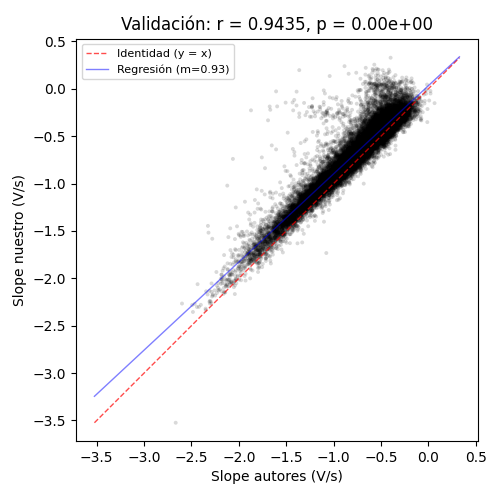

Correlación de Pearson: r = 0.9435
p-valor: 0.00e+00


In [28]:
# Filtrar donde ambos son válidos
valid = ~np.isnan(res['slope_ours']) & ~np.isnan(res['slope_authors'])
s_ours = res['slope_ours'][valid]
s_auth = res['slope_authors'][valid]

r, p = stats.pearsonr(s_ours, s_auth)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(s_auth, s_ours, alpha=0.15, s=8, color='black', edgecolors='none')

# Línea de identidad
lims = [min(s_auth.min(), s_ours.min()), max(s_auth.max(), s_ours.max())]
ax.plot(lims, lims, 'r--', alpha=0.7, linewidth=1, label='Identidad (y = x)')

# Regresión
slope_reg, intercept_reg = np.polyfit(s_auth, s_ours, 1)
x_reg = np.linspace(lims[0], lims[1], 100)
ax.plot(x_reg, slope_reg * x_reg + intercept_reg, 'b-', alpha=0.5, linewidth=1,
        label=f'Regresión (m={slope_reg:.2f})')

ax.set_xlabel('Slope autores (V/s)')
ax.set_ylabel('Slope nuestro (V/s)')
ax.set_title(f'Validación: r = {r:.4f}, p = {p:.2e}')
ax.legend(fontsize=8)
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

print(f"Correlación de Pearson: r = {r:.4f}")
print(f"p-valor: {p:.2e}")


---

## 5. Exploración interactiva: ¿cómo afectan los parámetros?

Cada vez que muevas un slider se recalculan todos los slopes — espera unos segundos.

### Preguntas para explorar:
- ¿Con d=2, la correlación es mejor o peor que con d=1?
- ¿Hay un tamaño de ventana óptimo?
- ¿Qué combinación de parámetros maximiza la correlación?

In [27]:
_cache = {}

def get_cached_results(d, samp_window):
    key = (d, samp_window)
    if key not in _cache:
        _cache[key] = batch_slope_extraction(data, sr=16000, samp_window=samp_window, d=d)
    return _cache[key]


def interactive_correlation(d, samp_window, color_by):
    res_temp = get_cached_results(d, samp_window)
    
    valid = ~np.isnan(res_temp['slope_ours']) & ~np.isnan(res_temp['slope_authors'])
    s_o = res_temp['slope_ours'][valid]
    s_a = res_temp['slope_authors'][valid]
    grp = res_temp['group'][valid]
    ph = res_temp['phase'][valid]
    
    if len(s_o) < 3:
        print("No hay suficientes datos válidos.")
        return
    
    r, p = stats.pearsonr(s_o, s_a)
    
    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    
    # --- Scatter ---
    if color_by == 'Ninguno':
        axs[0].scatter(s_a, s_o, alpha=0.15, s=8, color='black', edgecolors='none')
    elif color_by == 'Grupo':
        for g, color in [('shocked', '#d62728'), ('control', '#1f77b4')]:
            mask = grp == g
            axs[0].scatter(s_a[mask], s_o[mask], alpha=0.2, s=8, color=color,
                          edgecolors='none', label=g)
        axs[0].legend(fontsize=8)
    elif color_by == 'Fase':
        for f, color in [('pre', '#2ca02c'), ('post', '#ff7f0e')]:
            mask = ph == f
            axs[0].scatter(s_a[mask], s_o[mask], alpha=0.2, s=8, color=color,
                          edgecolors='none', label=f)
        axs[0].legend(fontsize=8)
    
    lims = [min(s_a.min(), s_o.min()), max(s_a.max(), s_o.max())]
    axs[0].plot(lims, lims, 'r--', alpha=0.7, linewidth=1)
    axs[0].set_xlabel('Slope autores (V/s)')
    axs[0].set_ylabel('Slope nuestro (V/s)')
    axs[0].set_title(f'd={d}, ventana=\u00b1{samp_window} | r={r:.4f} (p={p:.1e})')
    axs[0].set_aspect('equal')
    
    # --- Residuos ---
    residuals = s_o - s_a
    axs[1].hist(residuals, bins=50, color='gray', edgecolor='black', linewidth=0.5, alpha=0.7)
    axs[1].axvline(0, color='red', linestyle='--', alpha=0.7)
    axs[1].axvline(residuals.mean(), color='blue', linestyle='-', alpha=0.7,
                   label=f'Media = {residuals.mean():.4f}')
    axs[1].set_xlabel('Residuo (nuestro - autores)')
    axs[1].set_ylabel('Frecuencia')
    axs[1].set_title('Distribución de diferencias')
    axs[1].legend(fontsize=8)
    
    fig.tight_layout()
    plt.show()
    
    print(f"  n = {len(s_o)} mediciones válidas")
    print(f"  Pearson r = {r:.4f}")
    print(f"  Media residuos = {residuals.mean():.4f} V/s")
    print(f"  SD residuos = {residuals.std():.4f} V/s")


w_corr = widgets.interactive(
    interactive_correlation,
    d=widgets.IntSlider(min=1, max=3, value=1, description='Orden deriv:'),
    samp_window=widgets.IntSlider(min=3, max=80, value=10, description='Ventana (\u00b1n):'),
    color_by=widgets.Dropdown(options=['Ninguno', 'Grupo', 'Fase'], value='Ninguno',
                               description='Colorear por:')
)
display(w_corr)

interactive(children=(IntSlider(value=1, description='Orden deriv:', max=3, min=1), IntSlider(value=10, descri…

<p>
  <img src="img/cat_dancing.gif"
       width="60"
       height="60"
       style="border-radius: 50%; object-fit: cover; border: 1px solid blue;" />
  <span style="color: blue; font-size: 40px;">Ejercicios</span>
</p>

### Observar:

1. d=1 vs d=2: ¿Cuál da mejor correlación?
2. Una ventana pequeña (3-5), ¿que efecto tiene en los residuos?
3. Una ventana grande (>40), ¿qu e efecto tiene en la correlación
4. Colorear por grupo/fase: ¿Algún subgrupo se desvía más?
